In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

In [2]:
df = pd.read_csv("Insurance_Charges_1/insurance.csv")

In [3]:
print(f'df.head() = \n{df.head()}')
print(f'\ndf.shape = \n{df.shape}')
print(f'\ndf.columns = \n{df.columns.tolist()}')
print(f"\ndf.info() = ")
df.info()

df.head() = 
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

df.shape = 
(1338, 7)

df.columns = 
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

df.info() = 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2),

In [4]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [5]:
print(df['sex'].unique().tolist())
print(df['smoker'].unique().tolist())
print(df['region'].unique().tolist())

['female', 'male']
['yes', 'no']
['southwest', 'southeast', 'northwest', 'northeast']


In [6]:
df.insert(loc=0, column='intercept', value=1)

df_encoded = pd.get_dummies(df, dtype=int, drop_first=True)

new_columns = [col for col in df_encoded.columns if col != 'charges'] + ['charges']
df_encoded = df_encoded[new_columns]

print(f'df.head() = \n{df.head()}')
print()
print(f'df_encoded.head() = \n{df_encoded.head()}')

df_encoded.to_csv("Insurance_Charges_1/cleaned_insurance_with_intercept.csv", index=False)
print("Successfully generated cleaned_insurance_with_intercept.csv")

df_order_2 = pd.get_dummies(df, dtype=int, drop_first=False)

cols = ['age', 'bmi', 'children', 'sex_female', 'sex_male', 'smoker_no', 'smoker_yes', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']
sex = ['sex_female', 'sex_male']
smoker = ['smoker_no', 'smoker_yes']
region = ['region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']


for i in range(3):
    for j in range(i,len(cols)):
        new_col = cols[i] + ' x ' + cols[j]
        df_order_2[new_col] = df_order_2[cols[i]] * df_order_2[cols[j]]

for col1 in sex:
    for col2 in smoker:
        new_col = col1 + ' x ' + col2
        df_order_2[new_col] = df_order_2[col1] * df_order_2[col2]
    
    for col2 in region:
        new_col = col1 + ' x ' + col2
        df_order_2[new_col] = df_order_2[col1] * df_order_2[col2]

for col1 in smoker:
    for col2 in region:
        new_col = col1 + ' x ' + col2
        df_order_2[new_col] = df_order_2[col1] * df_order_2[col2]

new_order_2_columns = [col for col in df_order_2.columns if col != 'charges'] + ['charges']
df_order_2 = df_order_2[new_order_2_columns]

df_order_2.to_csv("Insurance_Charges_1/cleaned_order_2_insurance_with_intercept.csv", index=False)
print("Successfully generated cleaned_order_2_insurance_with_intercept.csv")

df.head() = 
   intercept  age     sex     bmi  children smoker     region      charges
0          1   19  female  27.900         0    yes  southwest  16884.92400
1          1   18    male  33.770         1     no  southeast   1725.55230
2          1   28    male  33.000         3     no  southeast   4449.46200
3          1   33    male  22.705         0     no  northwest  21984.47061
4          1   32    male  28.880         0     no  northwest   3866.85520

df_encoded.head() = 
   intercept  age     bmi  children  sex_male  smoker_yes  region_northwest  \
0          1   19  27.900         0         0           1                 0   
1          1   18  33.770         1         1           0                 0   
2          1   28  33.000         3         1           0                 0   
3          1   33  22.705         0         1           0                 1   
4          1   32  28.880         0         1           0                 1   

   region_southeast  region_southwest   

In [7]:
print(f'\ndf_encoded.columns = \n{df_encoded.columns.tolist()}')


df_encoded.columns = 
['intercept', 'age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest', 'charges']


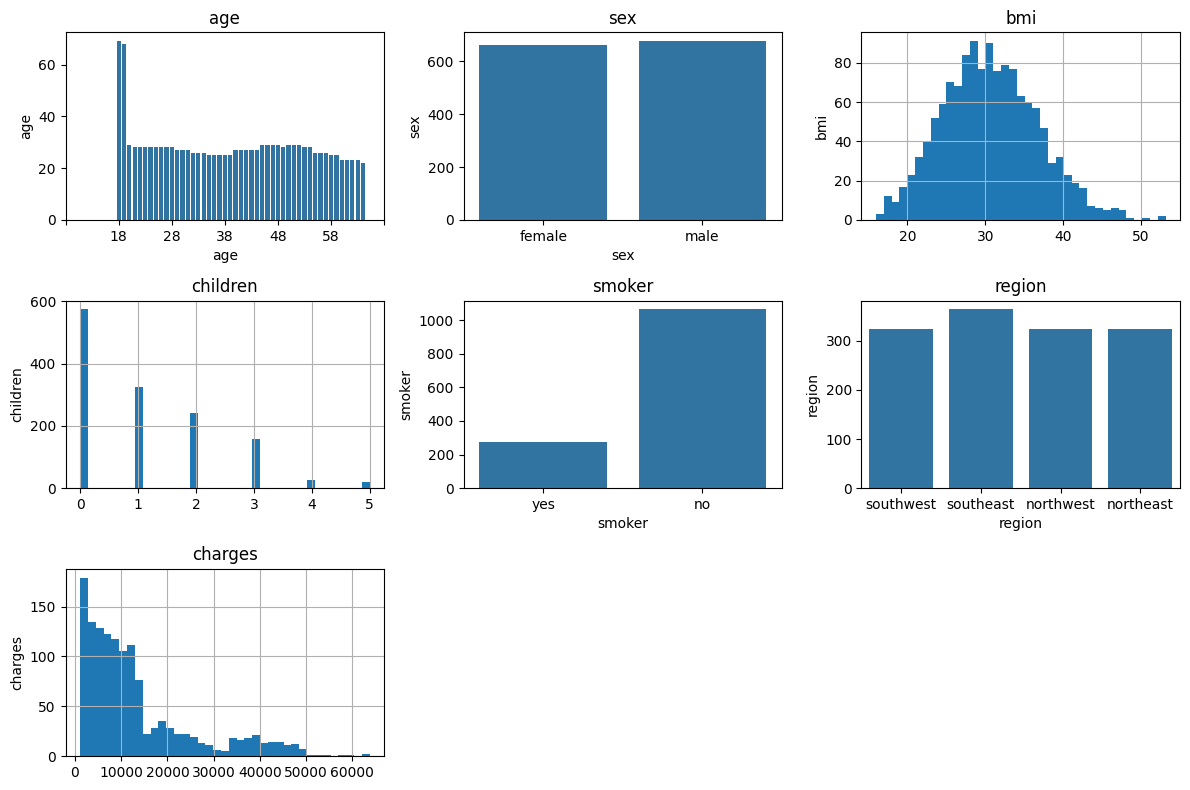

In [8]:
plt.figure(figsize=(12,8))
for i, col in enumerate(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']):
    plt.subplot(3,3,i+1)
    if col in ['sex', 'smoker', 'region']:
        sns.countplot(x=col, data=df)
    elif col == 'age':
        sns.countplot(x='age', data=df)
        plt.xticks(np.arange(-10, 57, step=10))
    else:
        df[col].hist(bins=37)
    plt.title(col)
    plt.ylabel(col)

plt.tight_layout()
plt.savefig('Insurance_Charges_1/histograms.png',dpi=400,bbox_inches='tight')
plt.show()

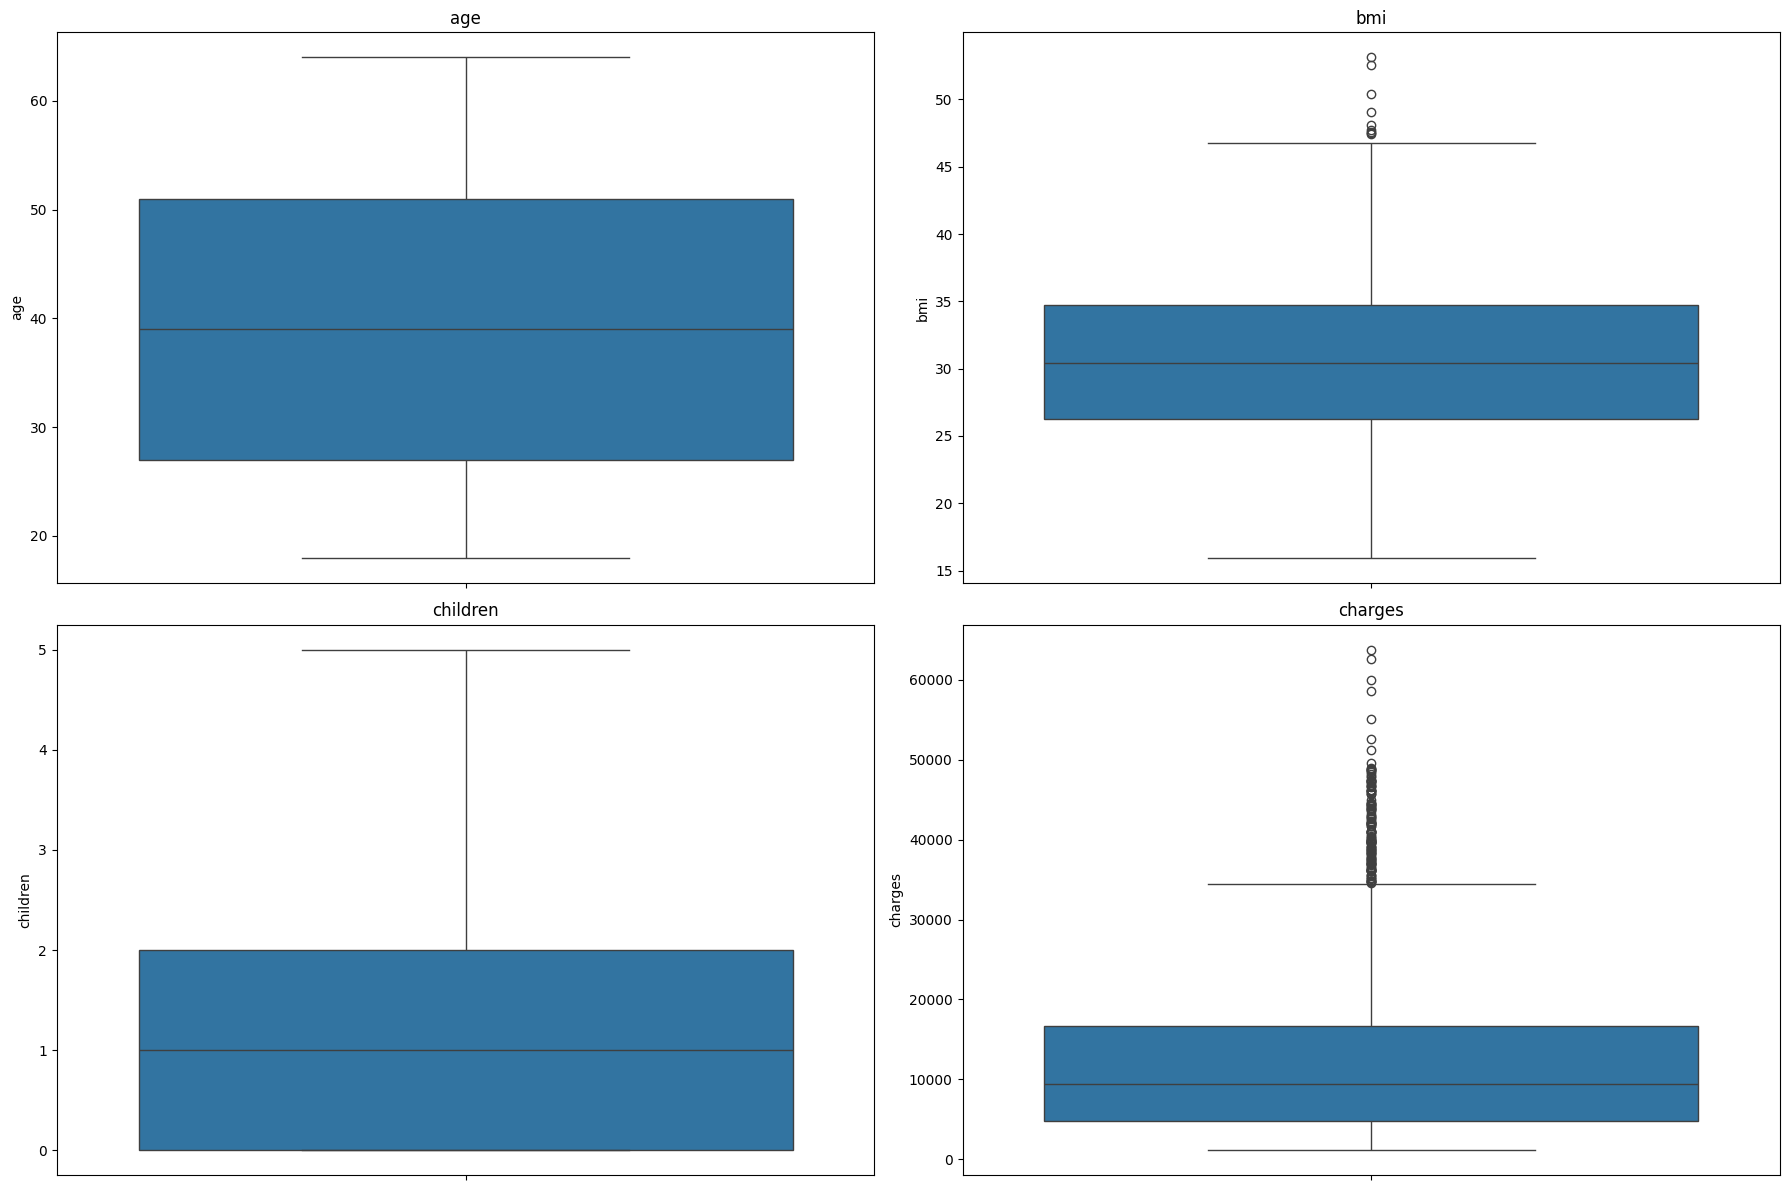

In [9]:
plt.figure(figsize=(18,12))
for i, col in enumerate(['age', 'bmi', 'children', 'charges']):
    plt.subplot(2,2,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.ylabel(col)

plt.tight_layout()
plt.savefig('Insurance_Charges_1/boxplots.png',dpi=400,bbox_inches='tight')
plt.show()

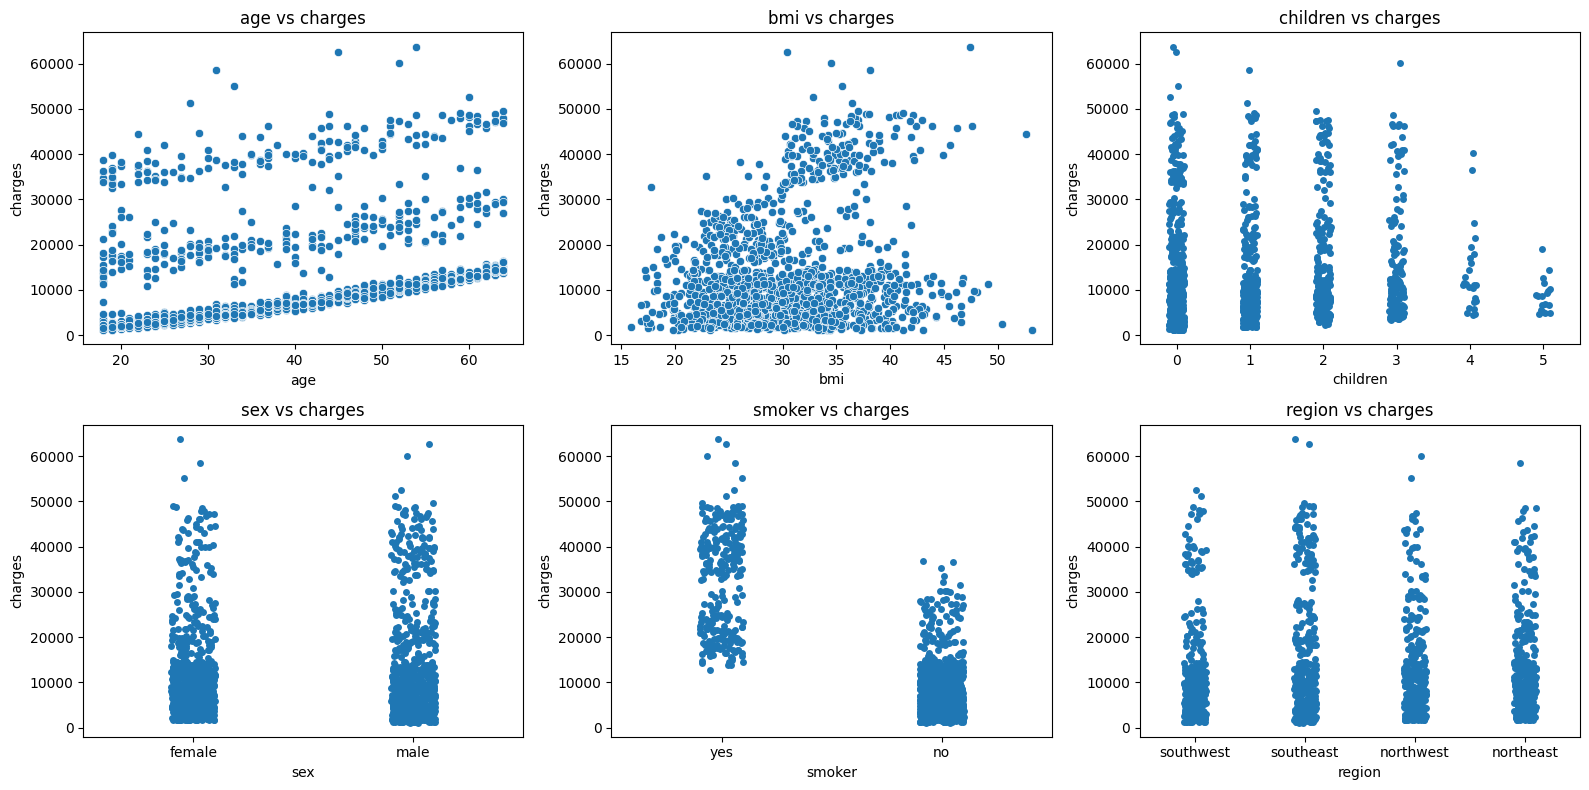

In [10]:
df['children'] = df['children'].astype('category')
features = ['age', 'bmi', 'children', 'sex', 'smoker', 'region']
cats = ['children', 'sex', 'smoker', 'region']

plt.figure(figsize=(16,8))

for i, col in enumerate(features):
    plt.subplot(2,3,i+1)
    if col not in cats:
        sns.scatterplot(x=df[col], y=df['charges'])
    else:
        sns.stripplot(x=df[col], y=df['charges'])
    plt.title(f"{col} vs charges")

plt.tight_layout()
plt.savefig('Insurance_Charges_1/scatterplots.png',dpi=400,bbox_inches='tight')
plt.show()

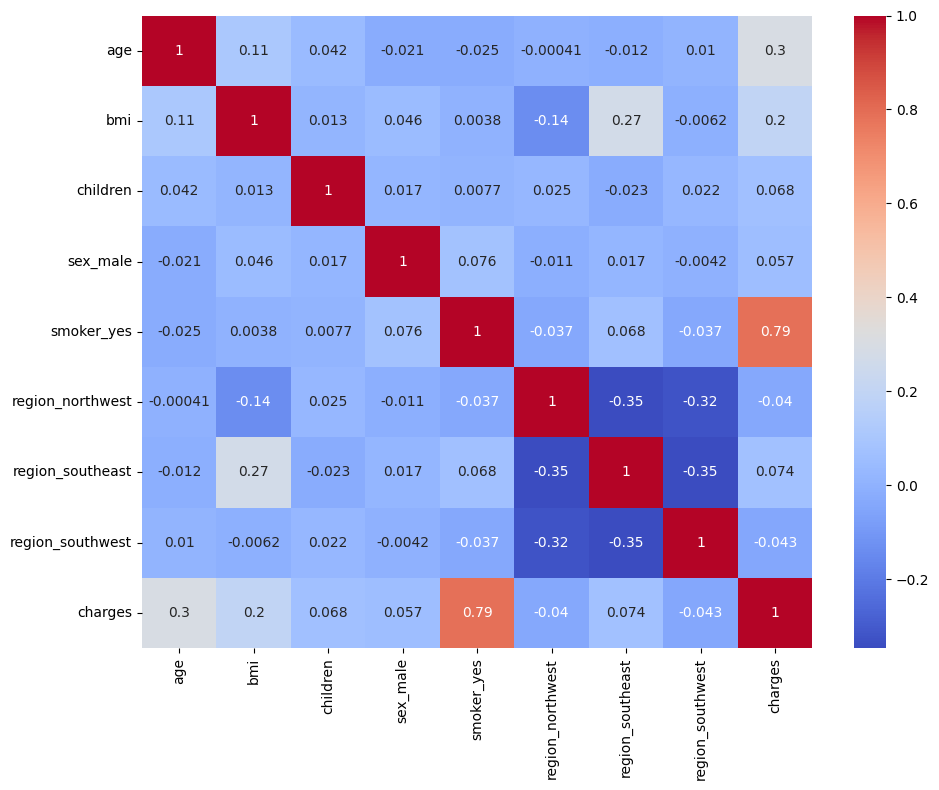

In [11]:
corr = df_encoded.drop('intercept', axis=1).corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr , annot = True , cmap = 'coolwarm')

plt.tight_layout()
plt.savefig('Insurance_Charges_1/correlation_heatmap.png',dpi = 300,bbox_inches='tight')
plt.show()

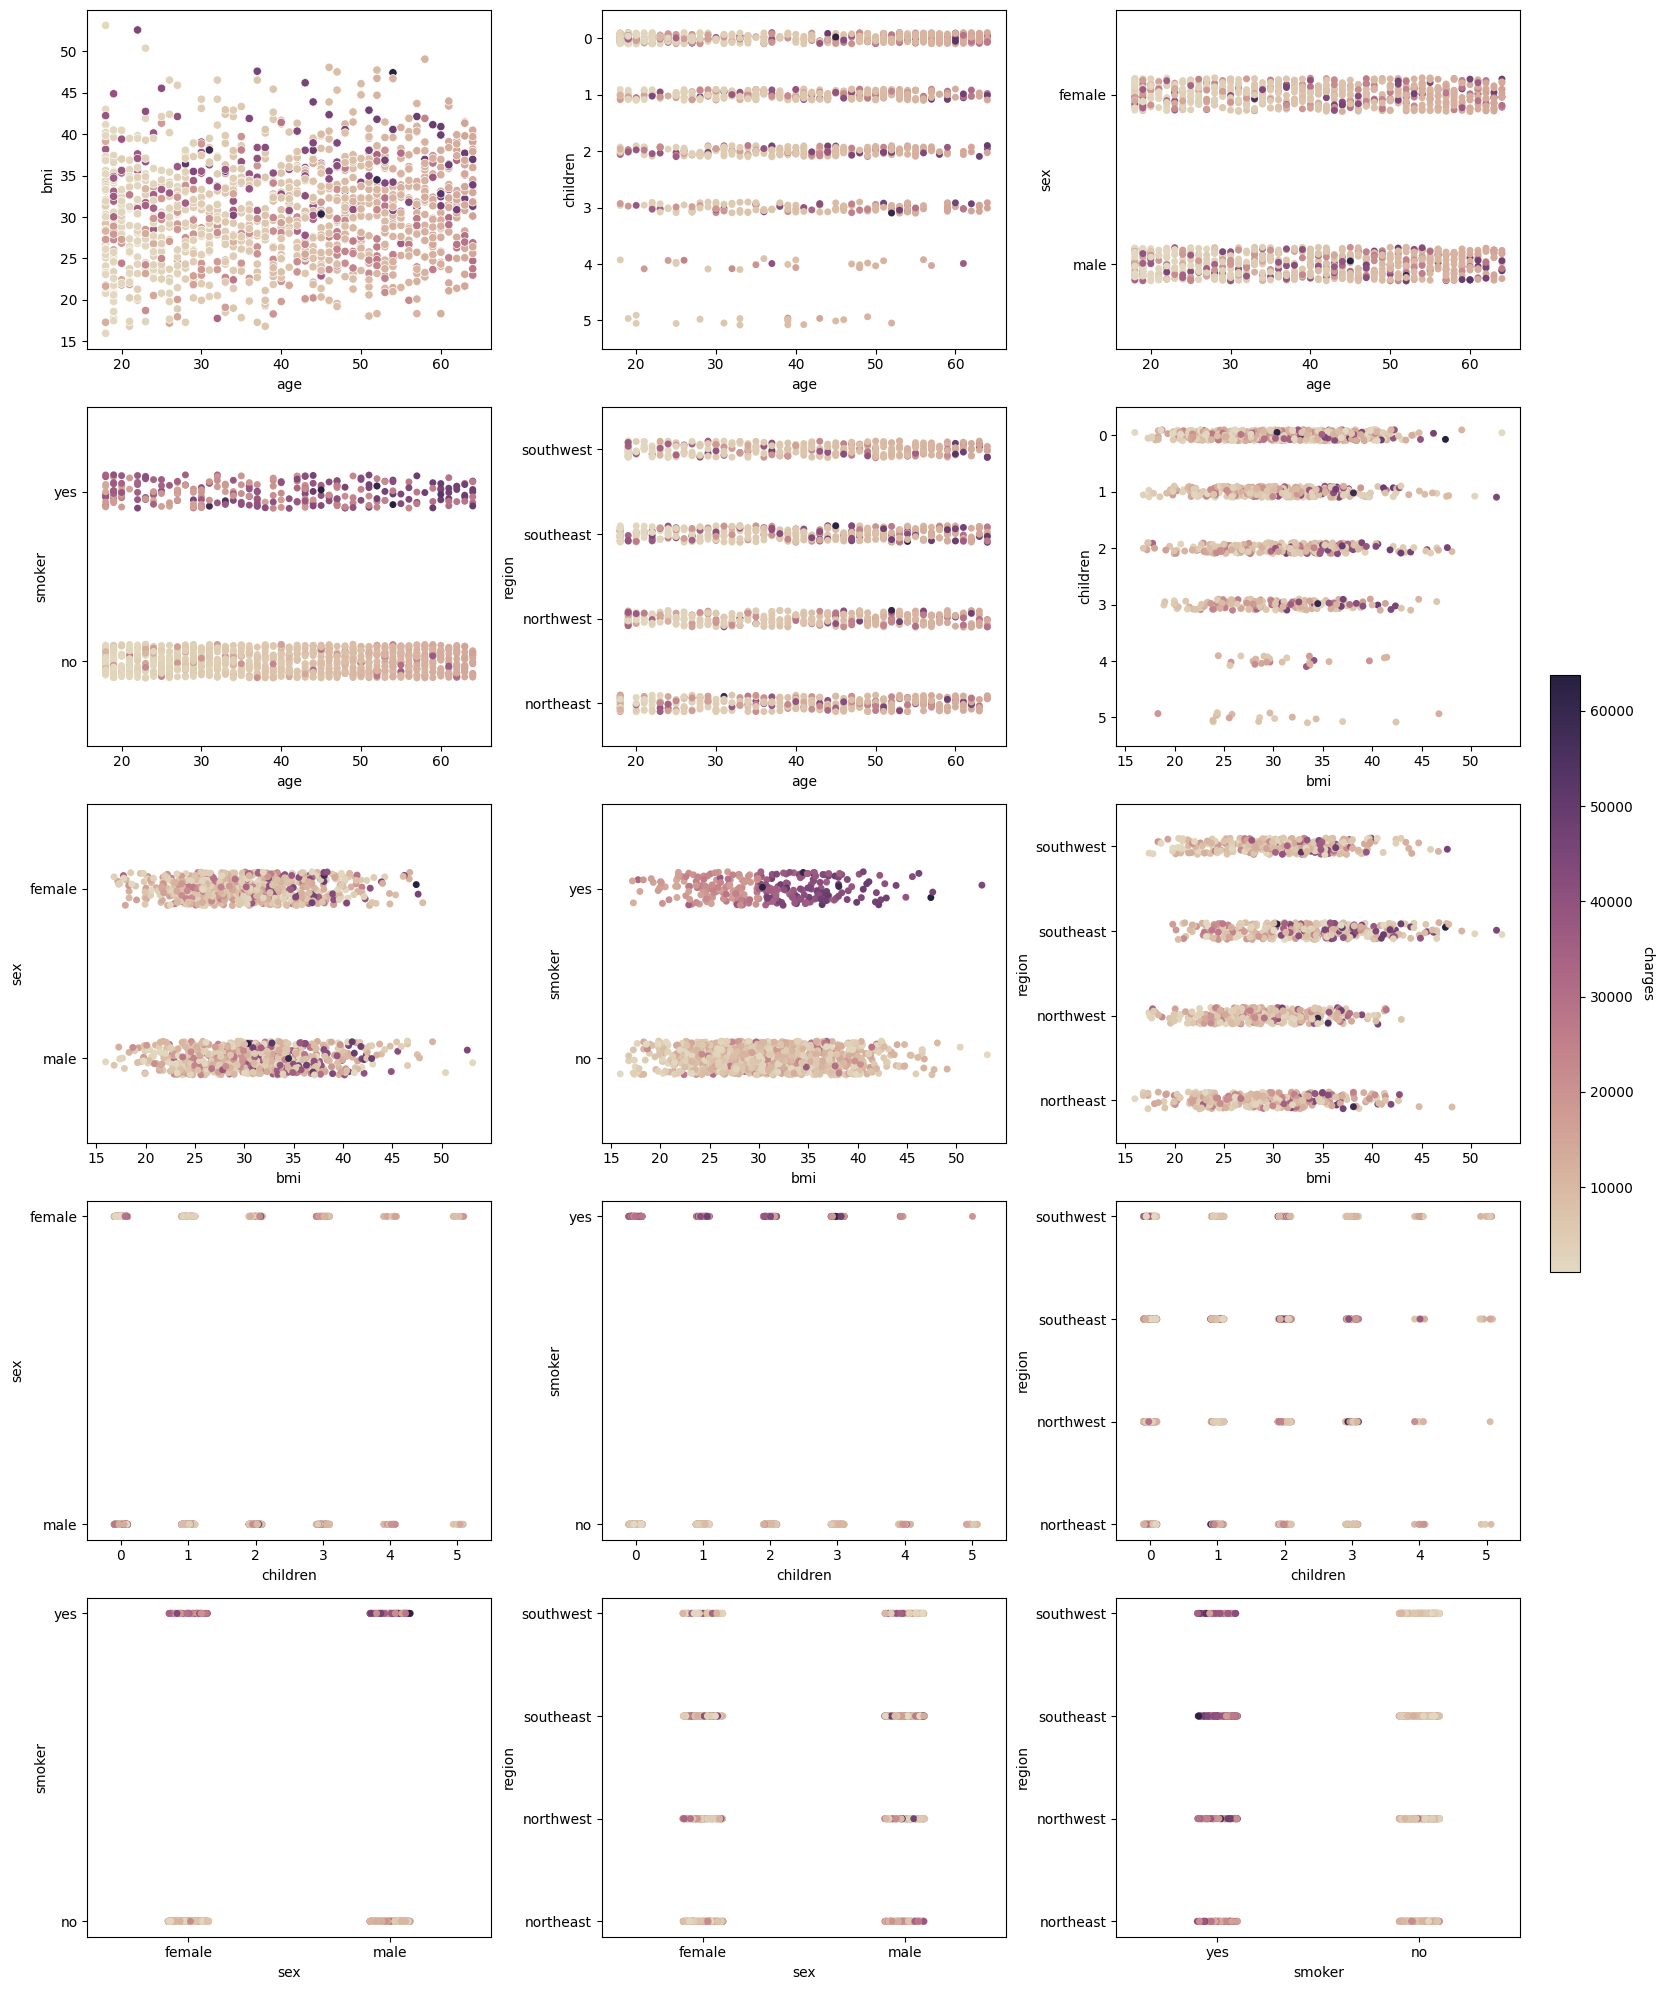

In [12]:
my_norm = colors.Normalize(vmin=df['charges'].min(), vmax=df['charges'].max())
# sns.cubehelix_palette(as_cmap=True)
my_cmap = sns.color_palette("ch:s=-.2,r=.6", as_cmap=True)

n = 1
fig = plt.figure(figsize=(16, 20))

for i in range(len(features)-1):
    for j in range(i+1, len(features)):
        plt.subplot(5, 3, n)
        
        if (features[i] not in cats) and (features[j] not in cats):
            sns.scatterplot(x=features[i], y=features[j], hue='charges', data=df, palette=my_cmap, hue_norm=my_norm, legend=False)
        else:
            sns.stripplot(x=features[i], y=features[j], hue='charges', data=df, palette=my_cmap, hue_norm=my_norm, legend=False)
        
        plt.xlabel(features[i])
        plt.ylabel(features[j])
        n = n + 1

plt.tight_layout()

sm = plt.cm.ScalarMappable(cmap=my_cmap, norm=my_norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=fig.axes, fraction=0.02, pad=0.02)
cbar.set_label('charges', rotation=270, labelpad=15)

plt.savefig('Insurance_Charges_1/Hue_Plots.png',dpi=400,bbox_inches='tight')
plt.show()